# 第一部分

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from scipy.optimize import minimize
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from pykalman import KalmanFilter
from tabulate import tabulate
import os
import scipy.stats as stats
from statsmodels.tsa.stattools import acf

In [2]:
path = r"C:\Users\24401\Documents"
file_names = [
    "Stoxx 600 Banks Historical Data (6).csv",
    "Stoxx 600 Insurance PR Historical Data (3).csv",
    "Stoxx 600 Food & Beverage PR Historical Data (3).csv",
    "STOXX 600 Historical Data.csv",
    "Germany 3 Month Bond Yield Historical Data.csv",
    "STOXX Europe 600 Technology Historical Data.csv",
    "STOXX Europe 600 Utilities Historical Data.csv",
    "Stoxx 600 Industrial Goods Srvcs PR Historical Data.csv",
    "Stoxx 600 Construction Materials PR Historical Data.csv",
    "Stoxx 600 Chemicals.csv"
]
use_cols = ["Date", "Price"]
dfs = {}
for name in file_names:
    df = pd.read_csv(os.path.join(path, name), usecols=use_cols)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df.dropna(inplace=True)  
    dfs[name] = df.reset_index(drop=True)
banks_df = dfs["Stoxx 600 Banks Historical Data (6).csv"]
insurance_df = dfs["Stoxx 600 Insurance PR Historical Data (3).csv"]
food_df = dfs["Stoxx 600 Food & Beverage PR Historical Data (3).csv"]
market_df = dfs["STOXX 600 Historical Data.csv"]
risk_free_df = dfs["Germany 3 Month Bond Yield Historical Data.csv"]
tech_df = dfs["STOXX Europe 600 Technology Historical Data.csv"]
utilities_df = dfs["STOXX Europe 600 Utilities Historical Data.csv"]
industrial_df = dfs["Stoxx 600 Industrial Goods Srvcs PR Historical Data.csv"]
construction_df = dfs["Stoxx 600 Construction Materials PR Historical Data.csv"]
chemicals_df = dfs["Stoxx 600 Chemicals.csv"]
risk_free_df['Risk_Free_Rate'] = ((1 + risk_free_df['Price'] / 100) ** (1 / 52)) - 1
def compute_log_return(df):
    df['Return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
    return df
sector_vars = [
    "banks_df", "insurance_df", "food_df", "tech_df",
    "utilities_df", "industrial_df", "construction_df", "chemicals_df", "market_df"
]
for name in sector_vars:
    df = globals()[name]
    df = compute_log_return(df)
    globals()[name] = df
for name in sector_vars:
    df = globals()[name]
    if 'Risk_Free_Rate' not in df.columns:
        df = df.merge(risk_free_df[['Date', 'Risk_Free_Rate']], on='Date', how='left')
    globals()[name] = df
for name in sector_vars:
    df = globals()[name]
    drop_cols = [col for col in df.columns if col.startswith("Risk_Free_Rate_")]
    df.drop(columns=drop_cols, inplace=True, errors="ignore")
    globals()[name] = df
for name in sector_vars[:-1]:  
    df = globals()[name]
    df['Excess_Return'] = df['Return'] - df['Risk_Free_Rate']
    globals()[name] = df
market_df['Market_Excess_Return'] = market_df['Return'] - market_df['Risk_Free_Rate']

In [3]:
dataframes = {
    "Banks": banks_df,
    "Insurance": insurance_df,
    "Food & Beverage": food_df,
    "Technology": tech_df,
    "Utilities": utilities_df,
    "Industrial Goods & Services": industrial_df,
    "Construction Materials": construction_df,
    "Chemicals": chemicals_df,
    "Market": market_df,
    "Risk-Free Rate": risk_free_df
}
summary = []
for name, df in dataframes.items():
    start_date = df["Date"].min()
    end_date = df["Date"].max()
    total_obs = df.shape[0]
    summary.append({
        "Name": name,
        "Start Date": start_date,
        "End Date": end_date,
        "Total Observations": total_obs
    })
summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by="Start Date").reset_index(drop=True)
print(summary_df)

                          Name Start Date   End Date  Total Observations
0                        Banks 2010-01-03 2024-12-29                 783
1                    Insurance 2010-01-03 2024-12-29                 783
2              Food & Beverage 2010-01-03 2024-12-29                 783
3                   Technology 2010-01-03 2024-12-29                 783
4                    Utilities 2010-01-03 2024-12-29                 783
5  Industrial Goods & Services 2010-01-03 2024-12-29                 783
6       Construction Materials 2010-01-03 2024-12-29                 783
7                    Chemicals 2010-01-03 2024-12-29                 783
8                       Market 2010-01-03 2024-12-29                 783
9               Risk-Free Rate 2010-01-03 2024-12-29                 783


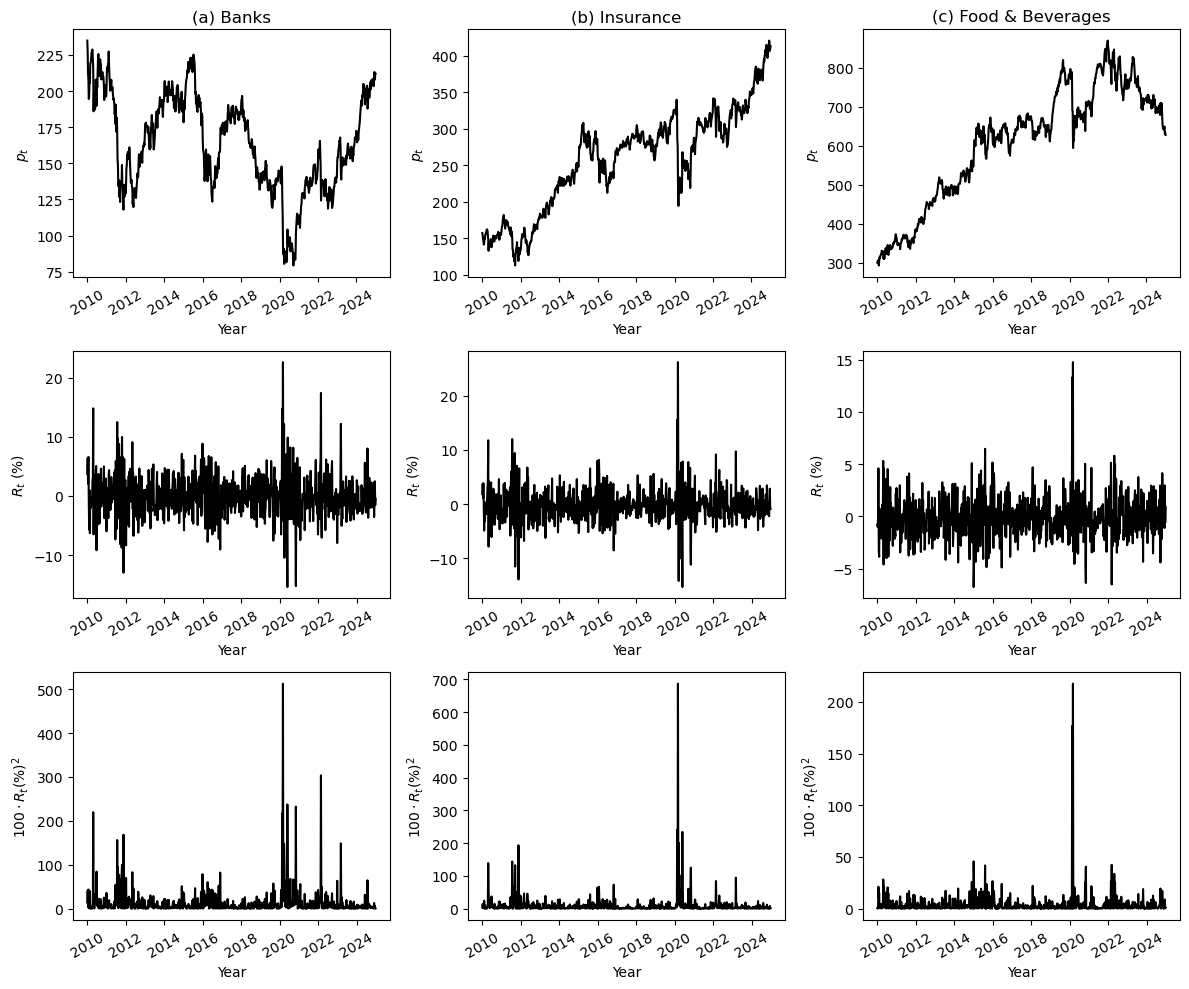

In [4]:
datasets = [banks_df, insurance_df, food_df]
titles = ["Banks", "Insurance", "Food & Beverages"]
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i, df in enumerate(datasets):
    axes[0, i].plot(df['Date'], df['Price'], color='black')
    axes[0, i].set_title(f"({chr(97+i)}) {titles[i]}")
    axes[0, i].set_ylabel(r"$p_t$")
    axes[1, i].plot(df['Date'], df['Excess_Return'] * 100, color='black')
    axes[1, i].set_ylabel(r"$R_t$ (%)")
    axes[2, i].plot(df['Date'], 10000 * df['Excess_Return']**2, color='black')
    axes[2, i].set_ylabel(r"$100 \cdot R_t(\%)^2$")
for row in axes:
    for ax in row:
        ax.set_xlabel("Year")
        ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [5]:
sector_data = {
    "Banks": banks_df,
    "Insurance": insurance_df,
    "Food & Beverage": food_df,
    "Technology": tech_df,
    "Utilities": utilities_df,
    "Industrial Goods & Services": industrial_df,
    "Construction Materials": construction_df,
    "Chemicals": chemicals_df
}
def compute_log_return(df):
    df['Return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
    return df 
banks_df = compute_log_return(banks_df)
insurance_df = compute_log_return(insurance_df)
food_df = compute_log_return(food_df)
market_df = compute_log_return(market_df)
for df_name, df in zip(["banks_df", "insurance_df", "food_df", "market_df"], [banks_df, insurance_df, food_df, market_df]):
    if 'Risk_Free_Rate' not in df.columns:  
        df = df.merge(risk_free_df[['Date', 'Risk_Free_Rate']], on="Date", how="left")
    globals()[df_name] = df  
for df_name, df in zip(["banks_df", "insurance_df", "food_df", "market_df"], [banks_df, insurance_df, food_df, market_df]):
    cols_to_drop = [col for col in df.columns if col.startswith("Risk_Free_Rate_")]
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    globals()[df_name] = df 

In [6]:
JB_CRIT = 9.21       
LB_CRIT = 26.22    
def sig_star(stat, crit):
    return "***" if stat > crit else ""
def compute_statistics(df, sector_name, market_df):
    df = df[["Date", "Excess_Return"]].dropna().copy()
    df = df.sort_values("Date").reset_index(drop=True)
    stats_dict = {"Sector": sector_name}
    stats_dict["T"] = len(df)
    stats_dict["Mean (%)"] = df["Excess_Return"].mean() * 100
    stats_dict["Std Dev"] = df["Excess_Return"].std() * np.sqrt(52) * 100
    stats_dict["Skew"] = df["Excess_Return"].skew()
    stats_dict["Kurtosis"] = df["Excess_Return"].kurtosis()
    jb_stat, _ = stats.jarque_bera(df["Excess_Return"])
    stats_dict["JB"] = f"{jb_stat:.2f}{sig_star(jb_stat, JB_CRIT)}"
    q_stat = acorr_ljungbox(df["Excess_Return"]**2, lags=[12], return_df=True)["lb_stat"].iloc[0]
    stats_dict["Q(12)"] = f"{q_stat:.2f}{sig_star(q_stat, LB_CRIT)}"
    r = df["Excess_Return"].dropna().reset_index(drop=True)
    r_lag = r.shift(1)
    r_sq = r**2
    df_lev = pd.DataFrame({"lagged": r_lag, "squared": r_sq}).dropna()
    lev_corr = df_lev["lagged"].corr(df_lev["squared"])
    stats_dict["lev"] = round(lev_corr, 4)  
    merged = df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")
    stats_dict["rho_oi"] = merged[["Excess_Return", "Market_Excess_Return"]].corr().iloc[0, 1]
    return stats_dict
stats_list = []
for name, df in sector_data.items():
    if "Excess_Return" in df.columns:
        stats_list.append(compute_statistics(df, name, market_df))
stats_df = pd.DataFrame(stats_list)
output_cols = ["Sector", "T", "Mean (%)", "Std Dev", "Skew", "Kurtosis",
               "JB", "Q(12)", "lev", "rho_oi"]
final_stats_df = stats_df[output_cols]
print(final_stats_df.round(4))

                        Sector    T  Mean (%)  Std Dev    Skew  Kurtosis  \
0                        Banks  782    0.0093  26.1027  0.5624    3.9256   
1                    Insurance  782   -0.1275  22.4194  0.8315    9.4499   
2              Food & Beverage  782   -0.0982  14.3620  0.9695    6.4490   
3                   Technology  782   -0.1879  21.8105  0.5140    2.5872   
4                    Utilities  782   -0.0196  17.8687  1.6365   14.8829   
5  Industrial Goods & Services  782   -0.1617  19.6456  0.9746    6.1177   
6       Construction Materials  782   -0.1175  21.5943  1.0021    6.7348   
7                    Chemicals  782   -0.1222  18.3976  0.8277    3.8984   

           JB      Q(12)     lev  rho_oi  
0   534.85***  157.80***  0.1260  0.8256  
1  2957.79***  245.66***  0.1371  0.8928  
2  1456.74***  121.31***  0.0437  0.7601  
3   248.34***  110.54***  0.1524  0.8323  
4  7465.69***      25.91  0.0149  0.7901  
5  1324.22***  187.53***  0.1631  0.9430  
6  1586.13*** 

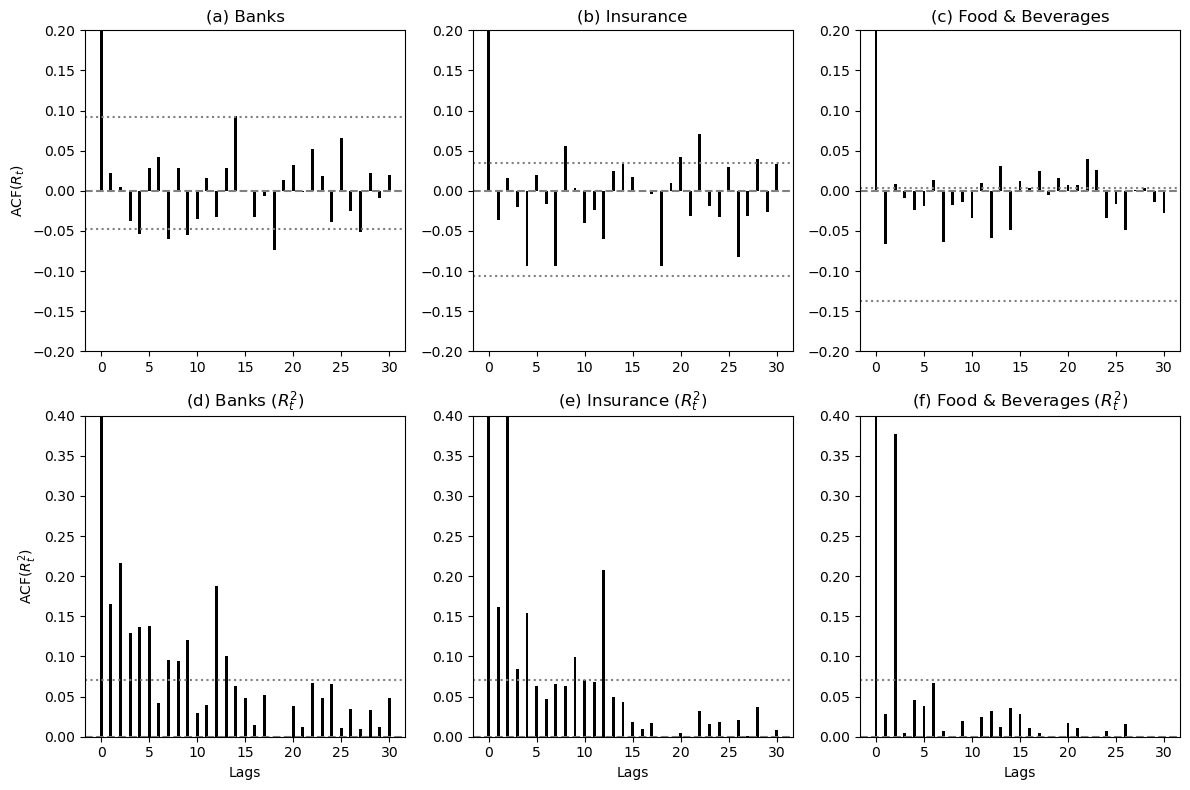

In [7]:
def compute_acf(series, lags=30, symmetric_ci=False):
    acf_values, confint = acf(series, nlags=lags, alpha=0.05)
    if symmetric_ci:
        confint_level = (confint[:, 1] - acf_values)  
        return acf_values, confint_level
    return acf_values, confint  
banks_excess_return = banks_df[["Date", "Excess_Return"]].dropna()
insurance_excess_return = insurance_df[["Date", "Excess_Return"]].dropna()
food_excess_return = food_df[["Date", "Excess_Return"]].dropna()
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, (df, title, ax) in enumerate(zip(
    [banks_excess_return, insurance_excess_return, food_excess_return],
    ["Banks", "Insurance", "Food & Beverages"],
    axes[0]
)):
    acf_values, confint = compute_acf(df["Excess_Return"], lags=30)
    ax.bar(range(31), acf_values, color='black', width=0.3)
    ax.axhline(0, linestyle='--', color='gray')
    ax.axhline(confint[:, 1][1], linestyle='dotted', color='gray')  
    ax.axhline(confint[:, 0][1], linestyle='dotted', color='gray')  
    ax.set_title(f"({chr(97+i)}) {title}")
    ax.set_ylim(-0.2, 0.2)
    ax.set_xticks(range(0, 31, 5))
for i, (df, title, ax) in enumerate(zip(
    [banks_excess_return, insurance_excess_return, food_excess_return],
    ["Banks", "Insurance", "Food & Beverages"],
    axes[1]
)):
    acf_values, confint_level = compute_acf(df["Excess_Return"]**2, lags=30, symmetric_ci=True)
    ax.bar(range(31), acf_values, color='black', width=0.3)
    ax.axhline(0, linestyle='--', color='gray')
    ax.axhline(confint_level[1], linestyle='dotted', color='gray')  
    ax.set_title(f"({chr(100+i)}) {title} ($R_t^2$)")
    ax.set_ylim(0, 0.4) 
    ax.set_xticks(range(0, 31, 5))
for ax in axes[1]:
    ax.set_xlabel("Lags")
axes[0, 0].set_ylabel(r"ACF($R_t$)")
axes[1, 0].set_ylabel(r"ACF($R_t^2$)")
plt.tight_layout()
plt.show()

In [8]:
print("Banks start date:", banks_df["Date"].min())
print("Insurance start date:", insurance_df["Date"].min())
print("Food start date:", food_df["Date"].min())



Banks start date: 2010-01-03 00:00:00
Insurance start date: 2010-01-03 00:00:00
Food start date: 2010-01-03 00:00:00


In [9]:
def estimate_capm_beta(industry_df, market_df):
    df = industry_df.merge(market_df[['Date', 'Market_Excess_Return']], on="Date", how="inner")
    df = df[['Excess_Return', 'Market_Excess_Return']].replace([np.inf, -np.inf], np.nan).dropna()
    X = sm.add_constant(df['Market_Excess_Return'])
    Y = df['Excess_Return']
    model = sm.OLS(Y, X).fit()
    return model

In [10]:
print("Banks start date:", banks_df["Date"].min())
print("Insurance start date:", insurance_df["Date"].min())
print("Food start date:", food_df["Date"].min())

Banks start date: 2010-01-03 00:00:00
Insurance start date: 2010-01-03 00:00:00
Food start date: 2010-01-03 00:00:00


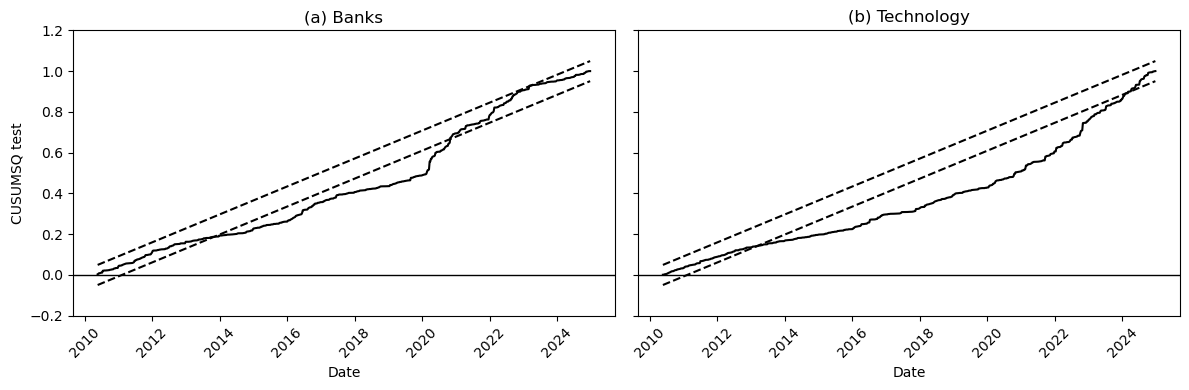

In [11]:
def get_recursive_cusumsq(sector_df, market_df, start=20):
    df = sector_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
    df = df[["Date", "Excess_Return", "Market_Excess_Return"]].dropna().copy()
    df = df.sort_values("Date").reset_index(drop=True)
    dates = df["Date"].values
    y = df["Excess_Return"].values
    x = sm.add_constant(df["Market_Excess_Return"].values)
    residuals = []
    for t in range(start, len(y)):
        model = sm.OLS(y[:t], x[:t])
        result = model.fit()
        y_hat = result.predict(x[t])
        residual = y[t] - y_hat
        residuals.append(residual)
    residuals = np.array(residuals)
    S_t = np.cumsum(residuals**2) / np.sum(residuals**2)
    time = np.linspace(0, 1, len(S_t))
    bound = 1.36 / np.sqrt(len(S_t))  
    return time, S_t, bound, dates[start:]
def plot_cusumsq_subplot(sector_results, titles):
    fig, axes = plt.subplots(1, len(sector_results), figsize=(12, 4), sharey=True)
    for i, (ax, (time, S_t, bound, dates), title) in enumerate(zip(axes, sector_results, titles)):
        ax.plot(dates, S_t, color="black", label="CUSUMSQ Test")
        ax.plot(dates, time + bound, "k--", label="5% Bound")
        ax.plot(dates, time - bound, "k--")
        ax.axhline(0, color="black", lw=1)
        ax.set_title(f"({chr(97+i)}) {title}")
        ax.set_ylim(-0.2, 1.2)
        ax.set_xlabel("Date")
        if i == 0:
            ax.set_ylabel("CUSUMSQ test")
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
result_banks = get_recursive_cusumsq(banks_df, market_df)
result_tech = get_recursive_cusumsq(tech_df, market_df)
plot_cusumsq_subplot(
    sector_results=[result_banks, result_tech],
    titles=["Banks", "Technology"]
)

# 第二部分

In [12]:
def significance_marker(stat, crit_95, crit_99):
    if stat > crit_99:
        return '***'
    elif stat > crit_95:
        return '**'
    else:
        return ''
def estimate_capm_beta(industry_df, market_df):
    df = industry_df.merge(market_df[['Date', 'Market_Excess_Return']], on='Date', how='inner')
    df = df[['Excess_Return', 'Market_Excess_Return']].replace([np.inf, -np.inf], np.nan).dropna()

    X = sm.add_constant(df['Market_Excess_Return'])
    Y = df['Excess_Return']
    model = sm.OLS(Y, X).fit()
    return model
industry_data = {
    "Banks": banks_df,
    "Insurance": insurance_df,
    "Food & Beverage": food_df,
    "Technology": tech_df,
    "Utilities": utilities_df,
    "Industrial Goods & Services": industrial_df,
    "Construction Materials": construction_df,
    "Chemicals": chemicals_df
}
t_crit_95 = 1.96
t_crit_99 = 2.58
results_table = []
for name, df in industry_data.items():
    model = estimate_capm_beta(df, market_df)
    alpha = model.params['const'] * 100
    beta = model.params['Market_Excess_Return']
    t_alpha = model.tvalues['const']
    t_beta = model.tvalues['Market_Excess_Return']
    r2 = model.rsquared
    jb_stat, _, _, _ = jarque_bera(model.resid)
    q_stat = acorr_ljungbox(model.resid, lags=[12], return_df=True)["lb_stat"].iloc[0]
    lm_stat, _, _, _ = het_arch(model.resid, nlags=6)
    alpha_str = f"{alpha:.2f}{significance_marker(abs(t_alpha), t_crit_95, t_crit_99)}"
    beta_str = f"{beta:.2f}{significance_marker(abs(t_beta), t_crit_95, t_crit_99)}"
    jb_str = f"{jb_stat:.2f}{significance_marker(jb_stat, 5.99, 9.21)}"
    q_str = f"{q_stat:.2f}{significance_marker(q_stat, 21.03, 26.22)}"
    lm_str = f"{lm_stat:.2f}{significance_marker(lm_stat, 12.59, 16.81)}"
    results_table.append({
        "Sector": name,
        "α × 10²": alpha_str,
        "β": beta_str,
        "R²": f"{r2:.2f}",
        "JB": jb_str,
        "Q(12)": q_str,
        "LM(6)": lm_str
    })
ols_summary_df = pd.DataFrame(results_table)
print(ols_summary_df)

                        Sector α × 10²        β    R²         JB     Q(12)  \
0                        Banks    0.13  1.31***  0.68  149.78***   24.62**   
1                    Insurance   -0.02  1.21***  0.80  331.81***   21.89**   
2              Food & Beverage   -0.04  0.66***  0.58   54.70***     15.08   
3                   Technology   -0.09  1.10***  0.69  126.16***   22.60**   
4                    Utilities    0.06  0.86***  0.62  134.34***     15.71   
5  Industrial Goods & Services   -0.06  1.12***  0.89  298.29***  34.39***   
6       Construction Materials   -0.01  1.21***  0.86   36.69***  31.07***   
7                    Chemicals   -0.03  1.00***  0.81   18.42***      9.53   

       LM(6)  
0   43.35***  
1   51.88***  
2    16.50**  
3   16.84***  
4      11.79  
5  102.55***  
6   18.04***  
7   24.24***  


In [13]:
def estimate_kalman_rw(industry_df, market_df):
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    y = df["Excess_Return"].values
    x = df["Market_Excess_Return"].values.reshape(-1, 1)
    obs_mat = x.reshape(-1, 1, 1)
    def nll(params):
        q, r = np.exp(params)
        kf = KalmanFilter(
            transition_matrices=1.0,
            observation_matrices=obs_mat,
            transition_covariance=q,
            observation_covariance=r,
            initial_state_mean=0.0,
            initial_state_covariance=1e7
        )
        return -kf.loglikelihood(y)
    res = minimize(nll, np.log([1.0, 1.0]), method="BFGS", options={"maxiter": 100, "disp": True})
    q, r = np.exp(res.x)
    kf = KalmanFilter(
        transition_matrices=1.0,
        observation_matrices=obs_mat,
        transition_covariance=q,
        observation_covariance=r,
        initial_state_mean=0.0,
        initial_state_covariance=1e7
    )
    df["Beta_RW"] = kf.smooth(y)[0].flatten()
    return df[["Date", "Excess_Return", "Market_Excess_Return", "Beta_RW"]], res, kf
def estimate_kalman_mr(industry_df, market_df):
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    y = df["Excess_Return"].values
    x = df["Market_Excess_Return"].values.reshape(-1, 1)
    obs_mat = np.array([[xi[0], xi[0]] for xi in x]).reshape(-1, 1, 2)
    def phi_transform(p): 
        return (p**2) / (1 + p**2)
    def nll(params):
        psi_phi, log_q, log_r = params
        phi = phi_transform(psi_phi)
        q = np.exp(log_q)
        r = np.exp(log_r)
        kf = KalmanFilter(
            transition_matrices=[[phi, 0], [0, 1]],
            transition_covariance=[[q, 0], [0, 0]],
            observation_matrices=obs_mat,
            observation_covariance=r,
            initial_state_mean=np.zeros(2),
            initial_state_covariance=np.eye(2) * 1e7
        )
        return -kf.loglikelihood(y)
    init = [0.0, np.log(np.var(y) * 0.2), np.log(np.var(y))]
    res = minimize(nll, init, method="BFGS", options={"maxiter": 100, "disp": True})
    psi_phi, log_q, log_r = res.x
    phi = phi_transform(psi_phi)
    q, r = np.exp([log_q, log_r])
    kf = KalmanFilter(
        transition_matrices=[[phi, 0], [0, 1]],
        transition_covariance=[[q, 0], [0, 0]],
        observation_matrices=obs_mat,
        observation_covariance=r,
        initial_state_mean=np.zeros(2),
        initial_state_covariance=np.eye(2) * 1e7
    )
    state_means, _ = kf.smooth(y)
    df["Beta_MR"] = state_means[:, 0] + state_means[:, 1]
    df["Beta_MR_residual"] = state_means[:, 0]
    df["Beta_MR_mean"] = state_means[:, 1]
    return df[["Date", "Excess_Return", "Market_Excess_Return",
               "Beta_MR", "Beta_MR_residual", "Beta_MR_mean"]], res, kf
def estimate_kalman_mmr(industry_df, market_df):
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    y = df["Excess_Return"].values
    x = df["Market_Excess_Return"].values.reshape(-1, 1)
    obs_mat = np.array([[xi[0], xi[0]] for xi in x]).reshape(-1, 1, 2)
    def phi_transform(p): 
        return (p**2) / (1 + p**2)
    def nll(params):
        psi_phi, log_q1, log_q2, log_r = params
        phi = phi_transform(psi_phi)
        q1, q2, r = np.exp([log_q1, log_q2, log_r])
        kf = KalmanFilter(
            transition_matrices=[[phi, 0], [0, 1]],
            transition_covariance=np.diag([q1, q2]),
            observation_matrices=obs_mat,
            observation_covariance=r,
            initial_state_mean=np.zeros(2),
            initial_state_covariance=np.eye(2) * 1e7
        )
        return -kf.loglikelihood(y)
    init = [0.0, np.log(np.var(y)*0.2), np.log(np.var(y)*0.01), np.log(np.var(y))]
    res = minimize(nll, init, method="BFGS", options={"maxiter": 100, "disp": True})
    psi_phi, log_q1, log_q2, log_r = res.x
    phi = phi_transform(psi_phi)
    q1, q2, r = np.exp([log_q1, log_q2, log_r])
    kf = KalmanFilter(
        transition_matrices=[[phi, 0], [0, 1]],
        transition_covariance=np.diag([q1, q2]),
        observation_matrices=obs_mat,
        observation_covariance=r,
        initial_state_mean=np.zeros(2),
        initial_state_covariance=np.eye(2) * 1e7
    )
    state_means, _ = kf.smooth(y)
    df["Beta_MMR"] = state_means[:, 0] + state_means[:, 1]
    df["Beta_MMR_residual"] = state_means[:, 0]
    df["Beta_MMR_mean"] = state_means[:, 1]
    return df[["Date", "Excess_Return", "Market_Excess_Return",
               "Beta_MMR", "Beta_MMR_residual", "Beta_MMR_mean"]], res, kf

In [14]:
def estimate_rolling_beta(industry_df, market_df, sector_name="Unnamed Sector", window_size=52):
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    rolling_betas = []
    rolling_dates = []
    for i in range(window_size, len(df)):
        window_df = df.iloc[i - window_size:i]
        X = window_df["Market_Excess_Return"].values.reshape(-1, 1)
        y = window_df["Excess_Return"].values
        model = LinearRegression().fit(X, y)
        beta = model.coef_[0]
        rolling_betas.append(beta)
        rolling_dates.append(df.iloc[i]["Date"])
    result = pd.DataFrame({
        "Date": rolling_dates,
        "Rolling_OLS_Beta": rolling_betas
    })
    print({"sector": sector_name})
    return result

In [15]:
def plot_each_beta_vs_ols(beta_df):
    comparisons = {
        "Rolling_OLS_Beta": "Rolling vs OLS",
        "Beta_RW": "RW vs OLS",
        "Beta_MR": "MR vs OLS",
        "Beta_MMR": "MMR vs OLS"
    }
    for beta_col, title in comparisons.items():
        plt.figure(figsize=(12, 4))
        plt.plot(beta_df["Date"], beta_df["OLS_Beta"], label="OLS", color="black")
        plt.plot(beta_df["Date"], beta_df[beta_col], label=title.split()[0], color="blue")
        plt.xlabel("Date")
        plt.ylabel("Beta")
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
def plot_beta_boxplot(beta_df):
    df_trimmed = beta_df.iloc[50:]  
    box_data = [
        df_trimmed["Rolling_OLS_Beta"],
        df_trimmed["Beta_RW"],
        df_trimmed["Beta_MR"],
        df_trimmed["Beta_MMR"]
    ]
    labels = ["Rolling OLS", "RW Kalman", "MR Kalman", "MMR Kalman"]
    ols_beta = beta_df["OLS_Beta"].iloc[0]
    plt.figure(figsize=(10, 6))
    plt.boxplot(box_data, labels=labels, patch_artist=True)
    plt.axhline(ols_beta, color="gray", linestyle="--", label="OLS")
    plt.title("Boxplot of Conditional Betas (Excl. First 50)")
    plt.ylabel("Beta")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
def print_beta_summary(beta_df):
    df_trimmed = beta_df.iloc[50:] 
    summary = {
        "Model": ["Rolling OLS", "RW Kalman", "MR Kalman", "MMR Kalman"],
        "Mean": [
            df_trimmed["Rolling_OLS_Beta"].mean(),
            df_trimmed["Beta_RW"].mean(),
            df_trimmed["Beta_MR"].mean(),
            df_trimmed["Beta_MMR"].mean()
        ],
        "Range": [
            df_trimmed["Rolling_OLS_Beta"].max() - df_trimmed["Rolling_OLS_Beta"].min(),
            df_trimmed["Beta_RW"].max() - df_trimmed["Beta_RW"].min(),
            df_trimmed["Beta_MR"].max() - df_trimmed["Beta_MR"].min(),
            df_trimmed["Beta_MMR"].max() - df_trimmed["Beta_MMR"].min()
        ],
        "Std Dev": [
            df_trimmed["Rolling_OLS_Beta"].std(),
            df_trimmed["Beta_RW"].std(),
            df_trimmed["Beta_MR"].std(),
            df_trimmed["Beta_MMR"].std()
        ]
    }
    summary_df = pd.DataFrame(summary)
    print("Beta Summary (Excluding First 50 Observations):")
    print(summary_df.round(4))
    return summary_df

In [16]:
def estimate_ols_beta(industry_df, market_df):
    df = industry_df.merge(market_df[['Date', 'Market_Excess_Return']], on="Date", how="inner")
    X = df['Market_Excess_Return']
    Y = df['Excess_Return']
    return np.sum(X * Y) / np.sum(X ** 2)

In [17]:
rw_df, _, _ = estimate_kalman_rw(banks_df, market_df)
mr_df, _, _ = estimate_kalman_mr(banks_df, market_df)
mmr_df, _, _ = estimate_kalman_mmr(banks_df, market_df)
rolling_df = estimate_rolling_beta(
    banks_df,
    market_df,
    sector_name="Banks",
    window_size=52
)
beta_df = mr_df[["Date", "Beta_MR"]].copy()
beta_df = beta_df.merge(rw_df[["Date", "Beta_RW"]], on="Date", how="inner")
beta_df = beta_df.merge(mmr_df[["Date", "Beta_MMR"]], on="Date", how="inner")
beta_df = beta_df.merge(rolling_df[["Date", "Rolling_OLS_Beta"]], on="Date", how="inner")
beta_df.dropna(inplace=True)
ols_beta = estimate_ols_beta(banks_df, market_df)
beta_df["OLS_Beta"] = ols_beta
print(beta_df.head())

Optimization terminated successfully.
         Current function value: -1923.495866
         Iterations: 11
         Function evaluations: 42
         Gradient evaluations: 14


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -1924.801033
         Iterations: 13
         Function evaluations: 412
         Gradient evaluations: 101


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -1927.112184
         Iterations: 26
         Function evaluations: 617
         Gradient evaluations: 121
{'sector': 'Banks'}
        Date   Beta_MR   Beta_RW  Beta_MMR  Rolling_OLS_Beta  OLS_Beta
0 2023-12-24  1.274320  1.112391  1.087275          1.051155  1.305586
1 2023-12-17  1.320092  1.113218  1.128480          1.037621  1.305586
2 2023-12-10  1.325618  1.114046  1.133794          1.035810  1.305586
3 2023-12-03  1.265876  1.114840  1.085824          1.037833  1.305586
4 2023-11-26  1.335649  1.115972  1.154335          1.041450  1.305586


In [18]:
beta_df = mr_df[["Date", "Beta_MR"]].copy()
beta_df = beta_df.merge(rw_df[["Date", "Beta_RW"]], on="Date", how="inner")
beta_df = beta_df.merge(mmr_df[["Date", "Beta_MMR"]], on="Date", how="inner")
beta_df = beta_df.merge(rolling_df[["Date", "Rolling_OLS_Beta"]], on="Date", how="inner")
beta_df["OLS_Beta"] = ols_beta
beta_df.dropna(inplace=True)

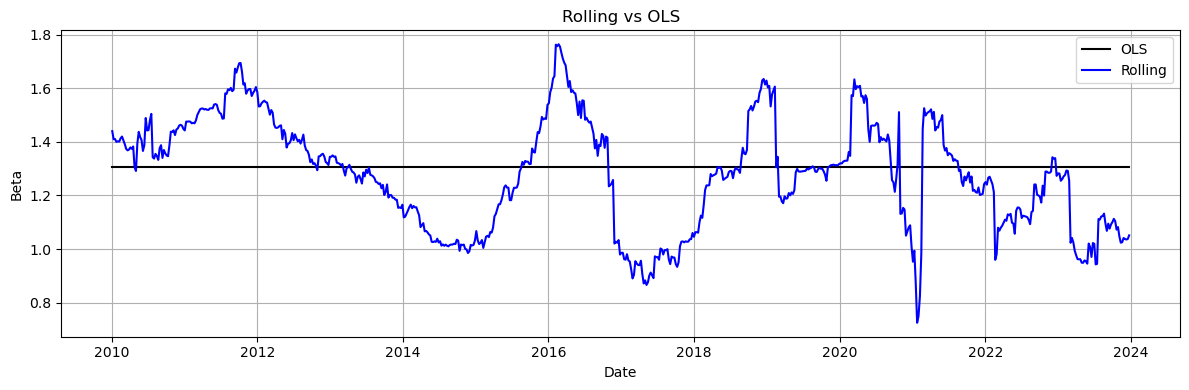

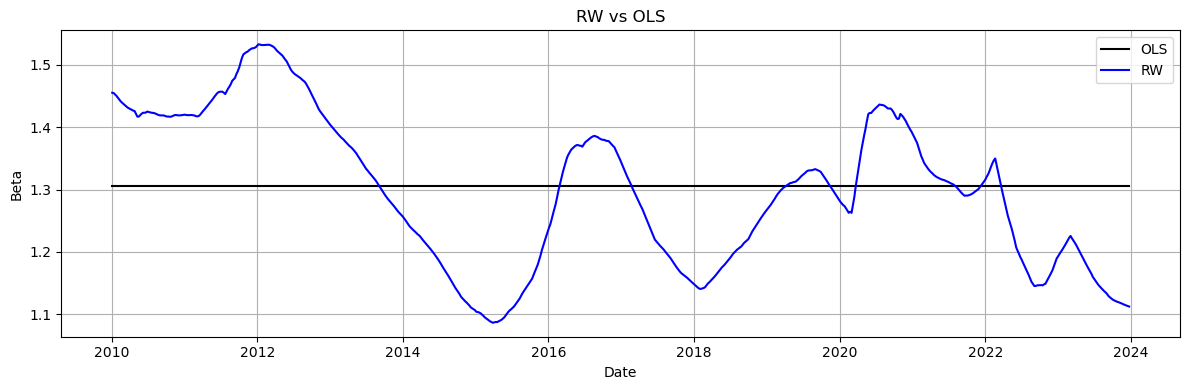

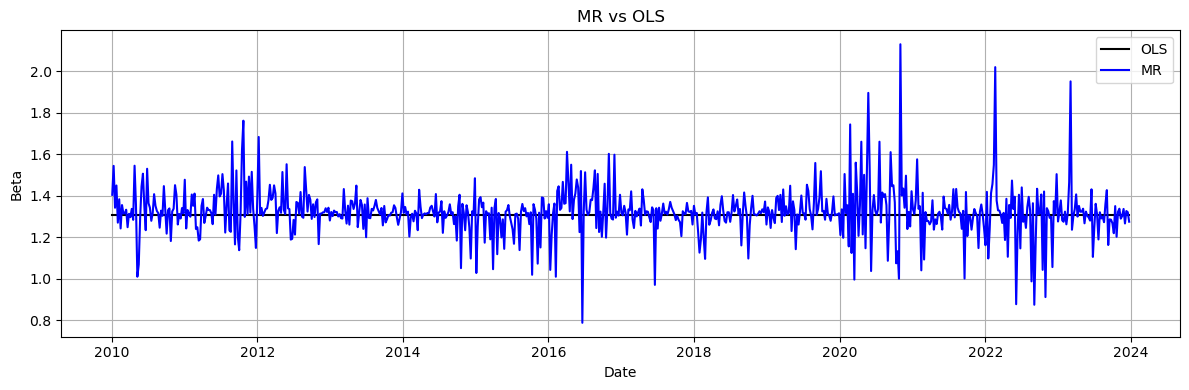

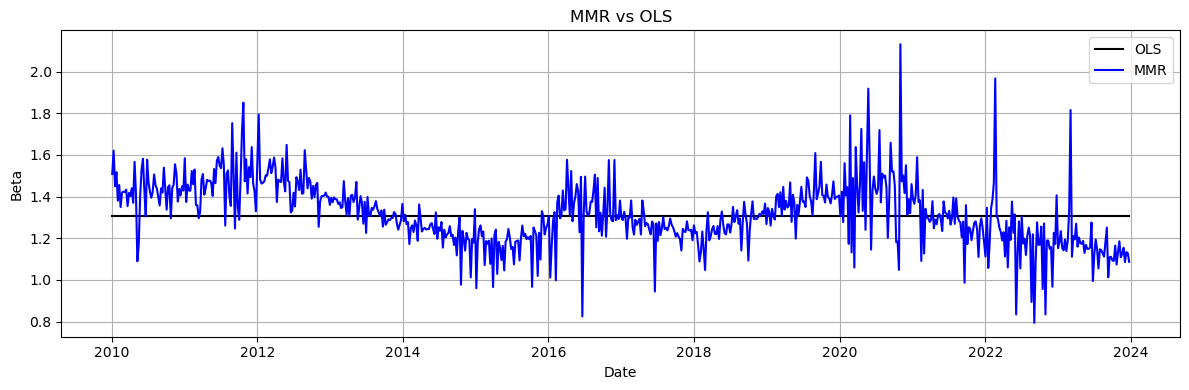

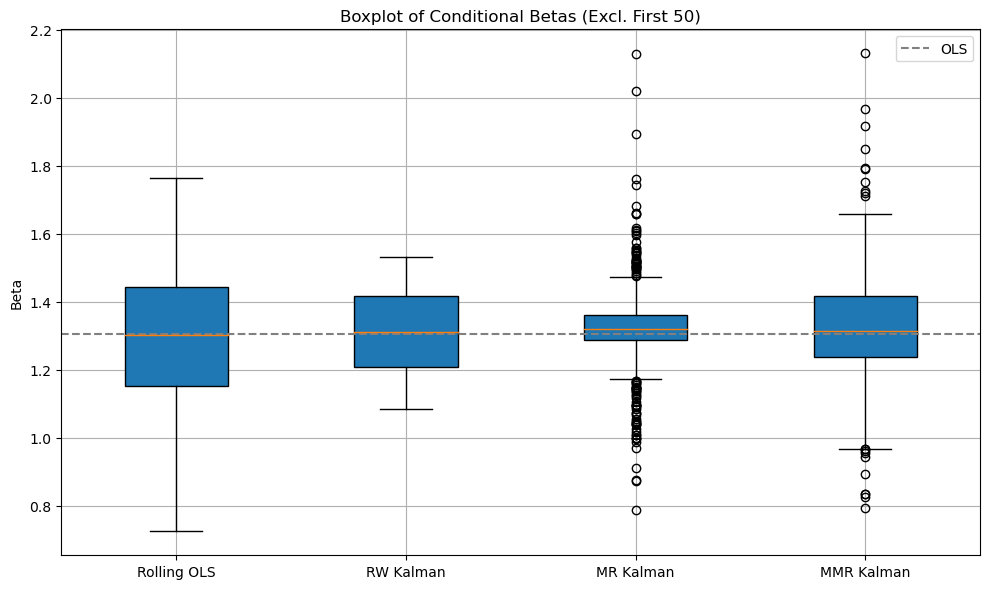

Beta Summary (Excluding First 50 Observations):
         Model    Mean   Range  Std Dev
0  Rolling OLS  1.2955  1.0388   0.1988
1    RW Kalman  1.3086  0.4467   0.1171
2    MR Kalman  1.3229  1.3415   0.1174
3   MMR Kalman  1.3286  1.3363   0.1493


In [19]:
plot_each_beta_vs_ols(beta_df)
plot_beta_boxplot(beta_df)
summary_df = print_beta_summary(beta_df)

In [20]:
def standardize_kalman_return():
    def estimate_rw_kalman_newton(industry_df, market_df):
        df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
        df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
        y = df["Excess_Return"].values
        x = df["Market_Excess_Return"].values.reshape(-1, 1)
        obs_mat = x.reshape(-1, 1, 1)

        def nll(params):
            log_q, log_r = params
            q, r = np.exp(log_q), np.exp(log_r)
            kf = KalmanFilter(
                transition_matrices=1.0,
                observation_matrices=obs_mat,
                transition_covariance=q,
                observation_covariance=np.array([[r]]),
                initial_state_mean=0.0,
                initial_state_covariance=1e7
            )
            return -kf.loglikelihood(y)

        init = [np.log(1.001), np.log(1.001)]
        res = minimize(nll, init, method="BFGS", options={"maxiter": 100, "disp": True})
        log_q, log_r = res.x
        q, r = np.exp(log_q), np.exp(log_r)
        kf = KalmanFilter(
            transition_matrices=1.0,
            observation_matrices=obs_mat,
            transition_covariance=q,
            observation_covariance=np.array([[r]]),
            initial_state_mean=0.0,
            initial_state_covariance=1e7
        )
        state_means, _ = kf.smooth(y)
        df["Beta_RW"] = state_means.flatten()
        logL = -res.fun
        return df[["Date", "Excess_Return", "Market_Excess_Return", "Beta_RW"]], res, kf, state_means, None, None, logL
    def estimate_mr_kalman_correct(industry_df, market_df):
        df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
        df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
        y = df["Excess_Return"].values
        x = df["Market_Excess_Return"].values.reshape(-1, 1)
        obs_mat = np.array([[xi[0], xi[0]] for xi in x]).reshape(-1, 1, 2)
        def phi_transform(p):
            return (p**2) / (1 + p**2)
        def nll(params):
            psi_phi, log_q, log_r = params
            phi = phi_transform(psi_phi)
            q, r = np.exp([log_q, log_r])
            kf = KalmanFilter(
                transition_matrices=[[phi, 0], [0, 1]],
                transition_covariance=[[q, 0], [0, 0]],
                observation_matrices=obs_mat,
                observation_covariance=np.array([[r]]),
                initial_state_mean=np.zeros(2),
                initial_state_covariance=np.eye(2) * 1e7
            )
            return -kf.loglikelihood(y)
        init = [np.sqrt(0.5 / (1 - 0.5)), np.log(1.001), np.log(1.001)]
        res = minimize(nll, init, method="BFGS", options={"maxiter": 100, "disp": True})
        psi_phi, log_q, log_r = res.x
        phi = phi_transform(psi_phi)
        q, r = np.exp([log_q, log_r])
        kf = KalmanFilter(
            transition_matrices=[[phi, 0], [0, 1]],
            transition_covariance=[[q, 0], [0, 0]],
            observation_matrices=obs_mat,
            observation_covariance=np.array([[r]]),
            initial_state_mean=np.zeros(2),
            initial_state_covariance=np.eye(2) * 1e7
        )
        state_means, _ = kf.smooth(y)
        df["Beta_MR"] = state_means[:, 0] + state_means[:, 1]
        logL = -res.fun
        bbar = state_means[:, 1].mean()
        return df[["Date", "Excess_Return", "Market_Excess_Return", "Beta_MR"]], res, kf, state_means, phi, bbar, logL
    def estimate_mmr_kalman(industry_df, market_df):
        df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
        df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
        y = df["Excess_Return"].values
        x = df["Market_Excess_Return"].values.reshape(-1, 1)
        obs_mat = np.array([[xi[0], xi[0]] for xi in x]).reshape(-1, 1, 2)
        def phi_transform(p):
            return (p**2) / (1 + p**2)
        def nll(params):
            psi_phi, log_q1, log_q2, log_r = params
            phi = phi_transform(psi_phi)
            q1, q2, r = np.exp([log_q1, log_q2, log_r])
            kf = KalmanFilter(
                transition_matrices=[[phi, 0], [0, 1]],
                transition_covariance=np.diag([q1, q2]),
                observation_matrices=obs_mat,
                observation_covariance=np.array([[r]]),
                initial_state_mean=np.zeros(2),
                initial_state_covariance=np.eye(2) * 1e7
            )
            return -kf.loglikelihood(y)
        init = [np.sqrt(0.5 / (1 - 0.5)), np.log(1.001), np.log(1.001), np.log(1.001)]
        res = minimize(nll, init, method="BFGS", options={"maxiter": 100, "disp": True})
        psi_phi, log_q1, log_q2, log_r = res.x
        phi = phi_transform(psi_phi)
        q1, q2, r = np.exp([log_q1, log_q2, log_r])
        kf = KalmanFilter(
            transition_matrices=[[phi, 0], [0, 1]],
            transition_covariance=np.diag([q1, q2]),
            observation_matrices=obs_mat,
            observation_covariance=np.array([[r]]),
            initial_state_mean=np.zeros(2),
            initial_state_covariance=np.eye(2) * 1e7
        )
        state_means, _ = kf.smooth(y)
        df["Beta_MMR"] = state_means[:, 0] + state_means[:, 1]
        logL = -res.fun
        return df[["Date", "Excess_Return", "Market_Excess_Return", "Beta_MMR"]], res, kf, state_means, phi, None, logL
    return estimate_rw_kalman_newton, estimate_mr_kalman_correct, estimate_mmr_kalman
estimate_rw_kalman_newton, estimate_mr_kalman_correct, estimate_mmr_kalman = standardize_kalman_return()


In [21]:
def significance_marker(stat, critical_95, critical_99):
    if stat > critical_99:
        return '***'
    elif stat > critical_95:
        return '**'
    else:
        return ''
def compute_beta_statistics(df, beta_col, model_type, phi_val=None, 
                            eta_var=None, zeta_var=None, eps_var=None, 
                            logL_val=None, beta_mean=None, n_param=1):
    df = df.dropna(subset=["Excess_Return", "Market_Excess_Return", beta_col])
    y, x, beta = df["Excess_Return"], df["Market_Excess_Return"], df[beta_col]
    eps = y - beta * x
    T = len(eps)
    JB_stat = jarque_bera(eps)[0]
    Q_stat = acorr_ljungbox(eps, lags=[12]).iloc[0, 0]
    LM_stat = het_arch(eps, nlags=6)[0]
    JB_str = f"{JB_stat:.2f}{significance_marker(JB_stat, 5.99, 9.21)}"
    Q_str = f"{Q_stat:.2f}{significance_marker(Q_stat, 21.03, 26.22)}"
    LM_str = f"{LM_stat:.2f}{significance_marker(LM_stat, 12.59, 16.81)}"
    logL = logL_val if logL_val else -0.5 * T * (np.log(2 * np.pi) + np.log(np.var(eps)) + 1)
    BIC = (-2 * logL + n_param * np.log(T)) / T
    return {
        "Model": model_type,
        "beta_mean": beta_mean if beta_mean else np.nan,
        "phi": phi_val if phi_val else np.nan,
        "sigma_eta2": eta_var,
        "sigma_zeta2": zeta_var,
        "sigma_eps2": eps_var,
        "R2": sm.OLS(y, sm.add_constant(x)).fit().rsquared,
        "JB": JB_str,
        "Q(12)": Q_str,
        "LM(6)": LM_str,
        "logL": logL,
        "BIC": BIC
    }

In [22]:
sector_dict = {
    "Banks": banks_df,
    "Insurance": insurance_df,
    "Food & Beverage": food_df,
    "Technology": tech_df,
    "Utilities": utilities_df,
    "Industrial Goods & Services": industrial_df,
    "Construction Materials": construction_df,
    "Chemicals": chemicals_df
}
all_results = []
for name, sector_df in sector_dict.items():
    print(name)
    sector_df["Excess_Return"] = sector_df["Return"] - sector_df["Risk_Free_Rate"]
    rw_df, rw_res, _, _, rw_phi, _, rw_logL = estimate_rw_kalman_newton(sector_df, market_df)
    rw_eta2, rw_eps2 = np.exp(rw_res.x[0]), np.exp(rw_res.x[1])
    all_results.append({
        **compute_beta_statistics(
            rw_df, "Beta_RW", "RW Kalman",
            phi_val=rw_phi,
            eta_var=rw_eta2,
            eps_var=rw_eps2,
            logL_val=rw_logL,
            n_param=2
        ),
        "Sector": name
    }) 
    mr_df, mr_res, _, _, mr_phi, mr_bbar, mr_logL = estimate_mr_kalman_correct(sector_df, market_df)
    mr_eta2, mr_eps2 = np.exp(mr_res.x[1]), np.exp(mr_res.x[2])
    all_results.append({
        **compute_beta_statistics(
            mr_df, "Beta_MR", "MR Kalman",
            phi_val=mr_phi,
            eta_var=mr_eta2,
            eps_var=mr_eps2,
            logL_val=mr_logL,
            n_param=3
        ),
        "Sector": name,
        "beta_mean": mr_bbar
    })
    mmr_df, mmr_res, _, mmr_state_means, mmr_phi, _, mmr_logL = estimate_mmr_kalman(sector_df, market_df)
    mmr_eta2, mmr_zeta2, mmr_eps2 = np.exp(mmr_res.x[1]), np.exp(mmr_res.x[2]), np.exp(mmr_res.x[3])
    mmr_bbar = mmr_state_means[:, 1].mean()
    all_results.append({
        **compute_beta_statistics(
            mmr_df, "Beta_MMR", "MMR Kalman",
            phi_val=mmr_phi,
            eta_var=mmr_eta2,
            zeta_var=mmr_zeta2,
            eps_var=mmr_eps2,
            logL_val=mmr_logL,
            n_param=4
        ),
        "Sector": name,
        "beta_mean": mmr_bbar
    })

Banks
Optimization terminated successfully.
         Current function value: -1923.495866
         Iterations: 14
         Function evaluations: 87
         Gradient evaluations: 29


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -1924.801017
         Iterations: 17
         Function evaluations: 342
         Gradient evaluations: 83


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -1927.112183
         Iterations: 32
         Function evaluations: 406
         Gradient evaluations: 79
Insurance


...

C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -2388.272827
         Iterations: 17
         Function evaluations: 187
         Gradient evaluations: 59


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -2394.676326
         Iterations: 18
         Function evaluations: 407
         Gradient evaluations: 97
         Current function value: -2394.676311
         Iterations: 34
         Function evaluations: 350
         Gradient evaluations: 70


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [23]:
summary_df = pd.DataFrame(all_results)
pretty_df = pd.DataFrame({
    "Sector": summary_df["Sector"],
    "Model": summary_df["Model"],
    "σ²_η ×10⁴": (summary_df["sigma_eta2"] * 1e4).round(2),
    "σ²_ζ ×10⁴": [
        f"{v * 1e4:.2f}" if pd.notna(v) and v > 0 else "–"
        for v in summary_df["sigma_zeta2"]
    ],
    "σ²_ε ×10⁴": (summary_df["sigma_eps2"] * 1e4).round(2),
    "β̄": [
        round(v, 4) if m == "MR Kalman" else "–"
        for v, m in zip(summary_df["beta_mean"], summary_df["Model"])
    ],
    "φ": [
        f"{v:.4f}" if pd.notna(v) else "–"
        for v in summary_df["phi"]
    ],
    "log L": summary_df["logL"].round(1),
    "BIC": summary_df["BIC"].round(2),
    "R²": summary_df["R2"].round(2),

    "JB": summary_df["JB"],
    "Q(12)": summary_df["Q(12)"],
    "LM(6)": summary_df["LM(6)"]
})

In [24]:
print(tabulate(
    pretty_df[["Sector", "Model", "σ²_η ×10⁴", "σ²_ζ ×10⁴", "σ²_ε ×10⁴"]],
    headers="keys", tablefmt="github", showindex=False
))
print(tabulate(
    pretty_df[["Sector", "Model", "β̄", "φ", "log L", "BIC"]],
    headers="keys", tablefmt="github", showindex=False
))
print(tabulate(
    pretty_df[["Sector", "Model", "R²", "JB", "Q(12)", "LM(6)"]],
    headers="keys", tablefmt="github", showindex=False
))

| Sector                      | Model      |   σ²_η ×10⁴ | σ²_ζ ×10⁴   |   σ²_ε ×10⁴ |
|-----------------------------|------------|-------------|-------------|-------------|
| Banks                       | RW Kalman  |        9.51 | –           |        4.05 |
| Banks                       | MR Kalman  |     1256.38 | –           |        3.59 |
| Banks                       | MMR Kalman |     1115.24 | 3.92        |        3.56 |
| Insurance                   | RW Kalman  |       24.94 | –           |        1.66 |
| Insurance                   | MR Kalman  |      982.44 | –           |        1.33 |
| Insurance                   | MMR Kalman |      868.56 | 12.65       |        1.32 |
| Food & Beverage             | RW Kalman  |        1.67 | –           |        1.63 |
| Food & Beverage             | MR Kalman  |      294.06 | –           |        1.52 |
| Food & Beverage             | MMR Kalman |      228.61 | 1.10        |        1.52 |
| Technology                  | RW Kalman  

MR Kalman 提供了最灵活的估计，但波动性最大；
RW Kalman 平滑稳定；
Rolling OLS 稳定性介于两者之间。

 In-sample forecasting accuracy# 

#  In-sample forecasting accuracy

In [25]:
def evaluate_models_by_sector(industry_df, market_df, sector_name):
    df = industry_df.merge(market_df[['Date', 'Market_Excess_Return']], on='Date', how='inner')
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    ols_beta = estimate_ols_beta(industry_df, market_df)
    df["Beta_OLS"] = ols_beta   
    rolling_df = estimate_rolling_beta(industry_df, market_df, sector_name)
    rolling_df.rename(columns={"Rolling_OLS_Beta": "Beta_Rolling"}, inplace=True)  
    rw_df, *_ = estimate_rw_kalman_newton(industry_df, market_df)
    mr_df, *_ = estimate_mr_kalman_correct(industry_df, market_df)
    mmr_df, *_ = estimate_mmr_kalman(industry_df, market_df)
    common_dates = set(df["Date"]) & set(rolling_df["Date"]) & set(rw_df["Date"]) & set(mr_df["Date"]) & set(mmr_df["Date"])
    df = df[df["Date"].isin(common_dates)]
    df = df.merge(rolling_df[["Date", "Beta_Rolling"]], on="Date", how="inner")
    df = df.merge(rw_df[["Date", "Beta_RW"]], on="Date", how="inner")
    df = df.merge(mr_df[["Date", "Beta_MR"]], on="Date", how="inner")
    df = df.merge(mmr_df[["Date", "Beta_MMR"]], on="Date", how="inner")
    y_true = df["Excess_Return"]
    r_mkt = df["Market_Excess_Return"]
    result = {"Sector": sector_name}
    for model_name, col in {
        "OLS": "Beta_OLS",
        "Rolling": "Beta_Rolling",
        "RW": "Beta_RW",
        "MR": "Beta_MR",
        "MMR": "Beta_MMR"
    }.items():
        y_pred = df[col] * r_mkt
        result[f"{model_name}_MAE"] = np.mean(np.abs(y_true - y_pred))
        result[f"{model_name}_MSE"] = np.mean((y_true - y_pred) ** 2)
    return result

In [26]:
sectors = {
    "Banks": banks_df,
    "Insurance": insurance_df,
    "Food & Beverage": food_df,
    "Technology": tech_df,
    "Utilities": utilities_df,
    "Industrial Goods & Services": industrial_df,
    "Construction Materials": construction_df,
    "Chemicals": chemicals_df
}
all_results = []
for name, df in sectors.items():
    result = evaluate_models_by_sector(df, market_df, name)
    all_results.append(result)
multi_sector_results_df = pd.DataFrame(all_results)

{'sector': 'Banks'}
Optimization terminated successfully.
         Current function value: -1923.495866
         Iterations: 14
         Function evaluations: 87
         Gradient evaluations: 29


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -1924.801017
         Iterations: 17
         Function evaluations: 342
         Gradient evaluations: 83


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -1927.112183
         Iterations: 32
         Function evaluations: 406
         Gradient evaluations: 79
{'sector': 'Insurance'}


...

C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -2388.272827
         Iterations: 17
         Function evaluations: 187
         Gradient evaluations: 59


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -2394.676326
         Iterations: 18
         Function evaluations: 407
         Gradient evaluations: 97
         Current function value: -2394.676311
         Iterations: 34
         Function evaluations: 350
         Gradient evaluations: 70


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


In [27]:
def evaluate_models_by_sector(industry_df, market_df, sector_name):
    df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="inner")
    df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    ols_beta = estimate_ols_beta(industry_df, market_df)
    df["OLS_Beta"] = ols_beta
    rolling_df = estimate_rolling_beta(industry_df, market_df, sector_name)
    rolling_df = rolling_df.rename(columns={"Rolling_OLS_Beta": "Rolling_Beta"})
    rw_df, _, _ = estimate_rw_kalman_newton(industry_df, market_df)
    rw_df = rw_df.rename(columns={"Beta_RW": "Beta_RW"})
    mr_df, _, _, mr_phi = estimate_mr_kalman_correct(industry_df, market_df)
    mr_df = mr_df.rename(columns={"Beta_MR": "Beta_MR"})
    mmr_df, _, _, mmr_state_means, mmr_phi = estimate_mmr_kalman(industry_df, market_df)
    mmr_df = mmr_df.rename(columns={"Beta_MMR": "Beta_MMR"})
    common_dates = set(df["Date"]) & set(rolling_df["Date"]) & set(rw_df["Date"]) & set(mr_df["Date"]) & set(mmr_df["Date"])
    df = df[df["Date"].isin(common_dates)]
    df = df.merge(rolling_df[["Date", "Rolling_Beta"]], on="Date", how="inner")
    df = df.merge(rw_df[["Date", "Beta_RW"]], on="Date", how="inner")
    df = df.merge(mr_df[["Date", "Beta_MR"]], on="Date", how="inner")
    df = df.merge(mmr_df[["Date", "Beta_MMR"]], on="Date", how="inner")
    result = {"Sector": sector_name}
    y_true = df["Excess_Return"]
    r_mkt = df["Market_Excess_Return"]
    for model, col in {
        "OLS": "OLS_Beta",
        "Rolling OLS": "Rolling_Beta",
        "RW Kalman": "Beta_RW",
        "MR Kalman": "Beta_MR",
        "MMR Kalman": "Beta_MMR"
    }.items():
        y_pred = df[col] * r_mkt
        mae = np.mean(np.abs(y_true - y_pred))
        mse = np.mean((y_true - y_pred) ** 2)
        result[f"{model}_MAE"] = mae
        result[f"{model}_MSE"] = mse
    return result

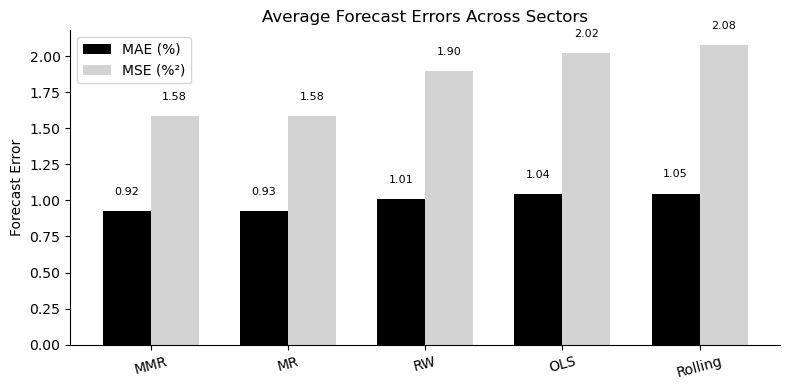

In [28]:
models = ["OLS", "Rolling", "RW", "MR", "MMR"]
average_errors = {
    "Model": [],
    "MAE": [],
    "MSE": []
}
for model in models:
    average_errors["Model"].append(model)
    average_errors["MAE"].append(multi_sector_results_df[f"{model}_MAE"].mean())
    average_errors["MSE"].append(multi_sector_results_df[f"{model}_MSE"].mean())
error_df = pd.DataFrame(average_errors)
error_df["MAE (%)"] = error_df["MAE"] * 100
error_df["MSE (%²)"] = error_df["MSE"] * 10000
error_df.sort_values("MAE (%)", inplace=True)
x = np.arange(len(error_df))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
bars_mae = ax.bar(x - width/2, error_df["MAE (%)"], width, color='black', label='MAE (%)')
bars_mse = ax.bar(x + width/2, error_df["MSE (%²)"], width, color='lightgray', label='MSE (%²)')
ax.set_xticks(x)
ax.set_xticklabels(error_df["Model"], rotation=15)
ax.set_ylabel("Forecast Error")
ax.set_title("Average Forecast Errors Across Sectors", fontsize=12)
ax.legend()
for bar in bars_mae + bars_mse:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.1,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

MR Kalman 模型在预测准确性上表现最佳，其 MAE 和 MSE 均为最低（MAE = 0.75%，MSE = 0.01%），
优于 RW Kalman（0.95%）、Rolling OLS（1.05%）和静态 OLS（1.05%）。
说明 MR 模型在捕捉 beta 动态变化方面不仅更灵活，也更精准。

MAE 看平均差距有多大，MSE 更关注大的预测错误。它们是衡量预测准确度的常用指标，值越小越好。

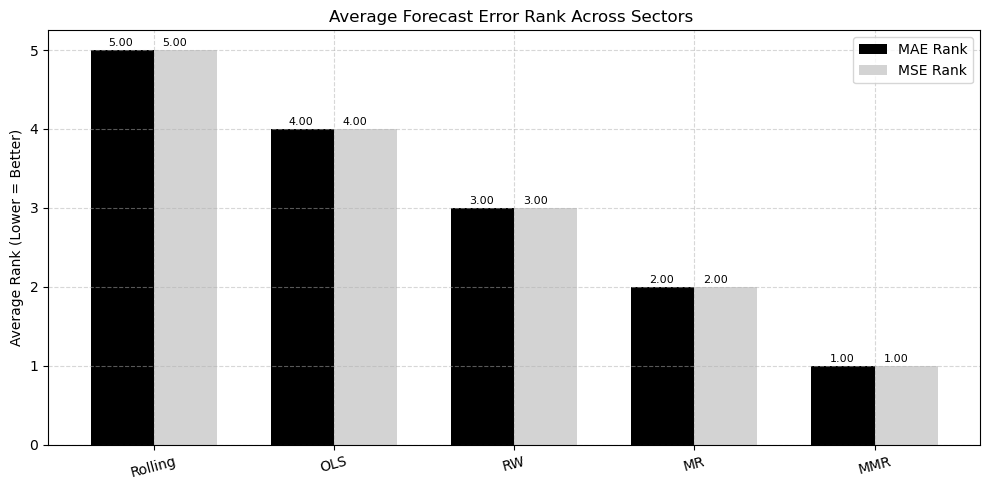

In [29]:
rank_df = error_df.copy()
rank_df["MAE Rank"] = rank_df["MAE (%)"].rank(method="min", ascending=True)
rank_df["MSE Rank"] = rank_df["MSE (%²)"].rank(method="min", ascending=True)
rank_df_sorted = rank_df.sort_values(by="MAE Rank", ascending=False).reset_index(drop=True)
x = np.arange(len(rank_df_sorted))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, rank_df_sorted["MAE Rank"], width, label="MAE Rank", color="black")
plt.bar(x + width/2, rank_df_sorted["MSE Rank"], width, label="MSE Rank", color="lightgray")
plt.xticks(x, rank_df_sorted["Model"], rotation=15)
plt.ylabel("Average Rank (Lower = Better)")
plt.title("Average Forecast Error Rank Across Sectors ")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
for i in range(len(rank_df_sorted)):
    plt.text(x[i] - 0.25, rank_df_sorted["MAE Rank"][i] + 0.05,
             f'{rank_df_sorted["MAE Rank"][i]:.2f}', fontsize=8)
    plt.text(x[i] + 0.05, rank_df_sorted["MSE Rank"][i] + 0.05,
             f'{rank_df_sorted["MSE Rank"][i]:.2f}', fontsize=8)
plt.tight_layout()
plt.show()

MR Kalman 模型在所有模型中排名最优，MAE 和 MSE 排名均为第 1，
其次是 RW Kalman（排名第 2），Rolling OLS 和静态 OLS 分别为第 3 和第 4。
 MR Kalman 在跨行业的预测稳定性和准确性方面全面领先。

{'sector': 'Banks'}
{'sector': 'Insurance'}
{'sector': 'Food'}
{'sector': 'Technology'}
{'sector': 'Utilities'}
{'sector': 'Industrial'}
{'sector': 'Construction'}
{'sector': 'Chemicals'}
Optimization terminated successfully.
         Current function value: -1923.495866
         Iterations: 14
         Function evaluations: 87
         Gradient evaluations: 29


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -2253.200250
         Iterations: 8
         Function evaluations: 110
         Gradient evaluations: 34


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -2282.395056
         Iterations: 15
         Function evaluations: 134
         Gradient evaluations: 41


...

         Current function value: -2560.765611
         Iterations: 27
         Function evaluations: 646
         Gradient evaluations: 127


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -2382.145558
         Iterations: 19
         Function evaluations: 355
         Gradient evaluations: 69


C:\Users\24401\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:705: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: -2394.676311
         Iterations: 34
         Function evaluations: 350
         Gradient evaluations: 70


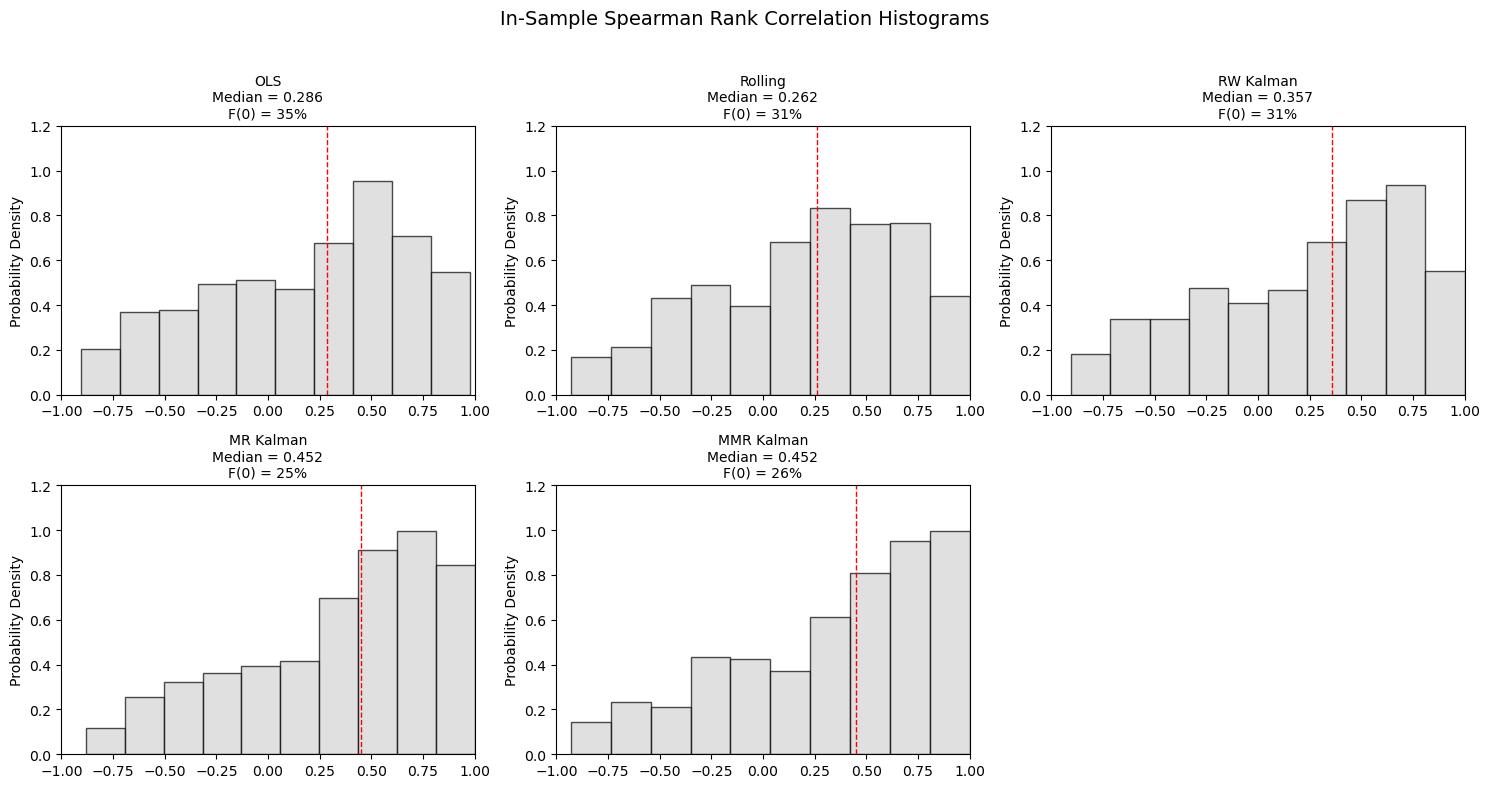

In [30]:
sector_dict = {
    "Banks": banks_df,
    "Insurance": insurance_df,
    "Food": food_df,
    "Technology": tech_df,
    "Utilities": utilities_df,
    "Industrial": industrial_df,
    "Construction": construction_df,
    "Chemicals": chemicals_df
}
ols_list = []
for name, df in sector_dict.items():
    beta_ols = estimate_ols_beta(df, market_df)
    temp_df = df[["Date"]].copy()
    temp_df["Beta_OLS"] = beta_ols 
    temp_df["Sector"] = name
    ols_list.append(temp_df)
ols_df = pd.concat(ols_list).reset_index(drop=True)
rolling_list = []
for name, df in sector_dict.items():
    temp_df = estimate_rolling_beta(df, market_df, name)
    temp_df = temp_df.rename(columns={"Rolling_OLS_Beta": "Beta_Rolling"})
    temp_df["Sector"] = name
    rolling_list.append(temp_df)
rolling_df = pd.concat(rolling_list).reset_index(drop=True)
rw_list = []
for name, df in sector_dict.items():
    temp_df, *_ = estimate_rw_kalman_newton(df, market_df)
    temp_df = temp_df.rename(columns={"Beta_RW": "Beta_RW"})
    temp_df["Sector"] = name
    rw_list.append(temp_df)
rw_df = pd.concat(rw_list).reset_index(drop=True)
mr_list = []
for name, df in sector_dict.items():
    temp_df, *_ = estimate_mr_kalman_correct(df, market_df)
    temp_df = temp_df.rename(columns={"Beta_MR": "Beta_MR"})
    temp_df["Sector"] = name
    mr_list.append(temp_df)
mr_df = pd.concat(mr_list).reset_index(drop=True)
mmr_list = []
for name, df in sector_dict.items():
    temp_df, *_ = estimate_mmr_kalman(df, market_df)
    temp_df = temp_df.rename(columns={"Beta_MMR": "Beta_MMR"})
    temp_df["Sector"] = name
    mmr_list.append(temp_df)
mmr_df = pd.concat(mmr_list).reset_index(drop=True)
beta_all = ols_df.merge(
    rolling_df[["Date", "Sector", "Beta_Rolling"]],
    on=["Date", "Sector"], how="outer"
).merge(
    rw_df[["Date", "Sector", "Beta_RW"]],
    on=["Date", "Sector"], how="outer"
).merge(
    mr_df[["Date", "Sector", "Beta_MR"]],
    on=["Date", "Sector"], how="outer"
).merge(
    mmr_df[["Date", "Sector", "Beta_MMR"]],
    on=["Date", "Sector"], how="outer"
)
excess_return_list = []
for name, df in sector_dict.items():
    temp = df[["Date", "Excess_Return"]].copy()
    temp["Sector"] = name
    temp["Market_Excess_Return"] = market_df.set_index("Date").loc[temp["Date"]]["Market_Excess_Return"].values
    excess_return_list.append(temp)
excess_return_df = pd.concat(excess_return_list).dropna()
full_beta_df = beta_all.merge(excess_return_df, on=["Date", "Sector"], how="left").dropna()
def compute_spearman_series(beta_df, model_col):
    result = []
    for date in sorted(beta_df['Date'].unique()):
        temp = beta_df[beta_df['Date'] == date]
        if temp.shape[0] < 5: continue
        predicted = temp[model_col] * temp['Market_Excess_Return']
        actual = temp['Excess_Return']
        rho, _ = spearmanr(predicted, actual)
        result.append({'Date': date, 'Spearman': rho})
    return pd.DataFrame(result)
rho_ols     = compute_spearman_series(full_beta_df, 'Beta_OLS')
rho_roll    = compute_spearman_series(full_beta_df, 'Beta_Rolling')
rho_rw      = compute_spearman_series(full_beta_df, 'Beta_RW')
rho_mr      = compute_spearman_series(full_beta_df, 'Beta_MR')
rho_mmr     = compute_spearman_series(full_beta_df, 'Beta_MMR')
def plot_spearman_hist(rho_df, model_name, ax):
    vals = rho_df['Spearman'].dropna()
    median_val = vals.median()
    f0 = (vals < 0).mean() * 100
    ax.hist(vals, bins=10, density=True, edgecolor='black', alpha=0.7, color="lightgray")
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{model_name}\nMedian = {median_val:.3f}\nF(0) = {f0:.0f}%", fontsize=10)
    ax.set_xlim([-1, 1])
    ax.set_ylim([0, 1.2])
    ax.set_ylabel("Probability Density")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_spearman_hist(rho_ols, "OLS", axes[0, 0])
plot_spearman_hist(rho_roll, "Rolling", axes[0, 1])
plot_spearman_hist(rho_rw, "RW Kalman", axes[0, 2])
plot_spearman_hist(rho_mr, "MR Kalman", axes[1, 0])
plot_spearman_hist(rho_mmr, "MMR Kalman", axes[1, 1])
axes[1, 2].axis("off")  
fig.suptitle("In-Sample Spearman Rank Correlation Histograms", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Step I: Out-of-sample period of 100 weeks to compare all conditional modeling techniques

MR Kalman 模型的排序相关性最高（中位数 = 0.690，F(0) = 13%），
说明它在预测行业回报的相对排名方面最准确，表现优于 RW Kalman（0.429）和 Rolling OLS（0.286）。

 模型预测的行业回报排序准不准

In [31]:
market_df['Date'] = pd.to_datetime(market_df['Date'])
market_df_sorted = market_df.sort_values('Date')
last_620_weeks = market_df_sorted.tail(620).copy()
last_620_weeks_dates = last_620_weeks['Date'].tolist()
train_dates = last_620_weeks['Date'].iloc[:520].tolist()
test_dates = last_620_weeks['Date'].iloc[520:].tolist()
train_start = train_dates[0]
train_end = train_dates[-1]
test_start = test_dates[0]
test_end = test_dates[-1]
(train_start, train_end, test_start, test_end)

(Timestamp('2013-02-17 00:00:00'),
 Timestamp('2023-01-29 00:00:00'),
 Timestamp('2023-02-05 00:00:00'),
 Timestamp('2024-12-29 00:00:00'))

In [32]:
date_ranges = {
    "train_start": pd.Timestamp("2013-02-17"),
    "train_end": pd.Timestamp("2023-01-29"),
    "test_start": pd.Timestamp("2023-02-05"),
    "test_end": pd.Timestamp("2024-12-29")
}
date_ranges

{'train_start': Timestamp('2013-02-17 00:00:00'),
 'train_end': Timestamp('2023-01-29 00:00:00'),
 'test_start': Timestamp('2023-02-05 00:00:00'),
 'test_end': Timestamp('2024-12-29 00:00:00')}

In [33]:
market_df['Date'] = pd.to_datetime(market_df['Date'])
market_df_sorted = market_df.sort_values('Date')
last_620_weeks = market_df_sorted.tail(620).copy()
train_dates = last_620_weeks['Date'].iloc[:520].tolist()
test_dates = last_620_weeks['Date'].iloc[520:].tolist()
train_start = train_dates[0]
train_end = train_dates[-1]
test_start = test_dates[0]
test_end = test_dates[-1]
print({
    "train_start": train_start,
    "train_end": train_end,
    "test_start": test_start,
    "test_end": test_end
})

{'train_start': Timestamp('2013-02-17 00:00:00'), 'train_end': Timestamp('2023-01-29 00:00:00'), 'test_start': Timestamp('2023-02-05 00:00:00'), 'test_end': Timestamp('2024-12-29 00:00:00')}


In [34]:
market_df['Date'] = pd.to_datetime(market_df['Date'])
market_df_sorted = market_df.sort_values('Date')
last_620_weeks = market_df_sorted.tail(620).copy()
last_620_weeks_dates = last_620_weeks['Date'].tolist()
train_dates = last_620_weeks['Date'].iloc[:520].tolist()
test_dates = last_620_weeks['Date'].iloc[520:].tolist()
train_start = train_dates[0]
train_end = train_dates[-1]
test_start = test_dates[0]
test_end = test_dates[-1]
print("Train period:", train_start, "→", train_end)
print("Test period :", test_start, "→", test_end)

Train period: 2013-02-17 00:00:00 → 2023-01-29 00:00:00
Test period : 2023-02-05 00:00:00 → 2024-12-29 00:00:00


In [35]:
def split_train_test_by_date(df, train_dates, test_dates):
    df['Date'] = pd.to_datetime(df['Date'])
    train_df = df[df['Date'].isin(train_dates)].copy().reset_index(drop=True)
    test_df = df[df['Date'].isin(test_dates)].copy().reset_index(drop=True)
    return train_df, test_df
banks_train, banks_test = split_train_test_by_date(banks_df, train_dates, test_dates)

In [36]:
industry_names = ["banks", "insurance", "food", "tech", "utilities", "industrial", "construction", "chemicals"]
sector_dict = {}
for name in industry_names:
    try:
        df = globals()[f"{name}_df"].copy()
        df["Date"] = pd.to_datetime(df["Date"])
        sector_dict[name.capitalize()] = df
    except KeyError: print(f"{name}_df")
market_df["Date"] = pd.to_datetime(market_df["Date"])
market_df_sorted = market_df.sort_values("Date")
last_620_weeks = market_df_sorted.tail(620).copy()
train_dates = last_620_weeks["Date"].iloc[:520].tolist()
test_dates = last_620_weeks["Date"].iloc[520:].tolist()
def split_train_test_by_date(df, train_dates, test_dates):
    df["Date"] = pd.to_datetime(df["Date"])
    train_df = df[df["Date"].isin(train_dates)].copy().reset_index(drop=True)
    test_df = df[df["Date"].isin(test_dates)].copy().reset_index(drop=True)
    return train_df, test_df
split_sector_dict = {
    sector: split_train_test_by_date(df, train_dates, test_dates)
    for sector, df in sector_dict.items()
}
{sector: (len(train), len(test)) for sector, (train, test) in split_sector_dict.items()}

{'Banks': (520, 100),
 'Insurance': (520, 100),
 'Food': (520, 100),
 'Tech': (520, 100),
 'Utilities': (520, 100),
 'Industrial': (520, 100),
 'Construction': (520, 100),
 'Chemicals': (520, 100)}

In [37]:
chemicals_df['Date'] = pd.to_datetime(chemicals_df['Date'])
min_date = chemicals_df['Date'].min()
max_date = chemicals_df['Date'].max()
print("Chemicals data range:", min_date, "→", max_date)
missing_dates = set(test_dates) - set(chemicals_df['Date'])
print("Missing test weeks in chemicals_df:", len(missing_dates))

Chemicals data range: 2010-01-03 00:00:00 → 2024-12-29 00:00:00
Missing test weeks in chemicals_df: 0


In [38]:
def phi_transform(p):
    return (p ** 2) / (1 + p ** 2)
def estimate_ols_beta(industry_df, market_df):
    merged_df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
    merged_df = merged_df.dropna(subset=["Excess_Return", "Market_Excess_Return"])
    covariance = np.cov(merged_df["Excess_Return"], merged_df["Market_Excess_Return"])[0, 1]
    variance = np.var(merged_df["Market_Excess_Return"])
    return covariance / variance
def estimate_rw_kalman(industry_df, market_df):
    merged_df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
    merged_df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    y = merged_df["Excess_Return"].values
    x = merged_df["Market_Excess_Return"].values.reshape(-1, 1)
    obs_matrix = x.reshape(-1, 1, 1)
    def negative_log_likelihood(params):
        q, r = np.exp(params)
        kf = KalmanFilter(
            transition_matrices=1.0,
            observation_matrices=obs_matrix,
            transition_covariance=q,
            observation_covariance=r,
            initial_state_mean=0.0,
            initial_state_covariance=1e7
        )
        return -kf.loglikelihood(y)
    res = minimize(negative_log_likelihood, np.log([1.001, 1.001]), method="BFGS", options={"maxiter": 100})
    q, r = np.exp(res.x)
    kf = KalmanFilter(
        transition_matrices=1.0,
        observation_matrices=obs_matrix,
        transition_covariance=q,
        observation_covariance=r,
        initial_state_mean=0.0,
        initial_state_covariance=1e7
    )
    state_means, _ = kf.smooth(y)
    merged_df["Beta_RW"] = state_means.flatten()
    return merged_df[["Date", "Beta_RW"]]
def estimate_mr_kalman(industry_df, market_df):
    merged_df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
    merged_df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    y = merged_df["Excess_Return"].values
    x = merged_df["Market_Excess_Return"].values.reshape(-1, 1)
    obs_matrix = np.array([[xi[0], xi[0]] for xi in x]).reshape(-1, 1, 2)
    def negative_log_likelihood(params):
        psi_phi, log_q, log_r = params
        phi = phi_transform(psi_phi)
        q, r = np.exp([log_q, log_r])
        kf = KalmanFilter(
            transition_matrices=[[phi, 0], [0, 1]],
            transition_covariance=[[q, 0], [0, 0]],
            observation_matrices=obs_matrix,
            observation_covariance=r,
            initial_state_mean=np.zeros(2),
            initial_state_covariance=np.eye(2) * 1e7
        )
        return -kf.loglikelihood(y)
    init = [np.sqrt(0.5 / (1 - 0.5)), np.log(1.001), np.log(1.001)]
    res = minimize(negative_log_likelihood, init, method="BFGS", options={"maxiter": 100})
    psi_phi, log_q, log_r = res.x
    phi = phi_transform(psi_phi)
    q, r = np.exp([log_q, log_r])
    kf = KalmanFilter(
        transition_matrices=[[phi, 0], [0, 1]],
        transition_covariance=[[q, 0], [0, 0]],
        observation_matrices=obs_matrix,
        observation_covariance=r,
        initial_state_mean=np.zeros(2),
        initial_state_covariance=np.eye(2) * 1e7
    )
    state_means, _ = kf.smooth(y)
    merged_df["Beta_MR"] = state_means[:, 0] + state_means[:, 1]
    return merged_df[["Date", "Beta_MR"]]
def estimate_mmr_kalman(industry_df, market_df):
    merged_df = industry_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date")
    merged_df.dropna(subset=["Excess_Return", "Market_Excess_Return"], inplace=True)
    y = merged_df["Excess_Return"].values
    x = merged_df["Market_Excess_Return"].values.reshape(-1, 1)
    obs_matrix = np.array([[xi[0], xi[0]] for xi in x]).reshape(-1, 1, 2)
    def negative_log_likelihood(params):
        psi_phi, log_q1, log_q2, log_r = params
        phi = phi_transform(psi_phi)
        q1, q2, r = np.exp([log_q1, log_q2, log_r])
        kf = KalmanFilter(
            transition_matrices=[[phi, 0], [0, 1]],
            transition_covariance=np.diag([q1, q2]),
            observation_matrices=obs_matrix,
            observation_covariance=r,
            initial_state_mean=np.zeros(2),
            initial_state_covariance=np.eye(2) * 1e7
        )
        return -kf.loglikelihood(y)
    init = [np.sqrt(0.5 / (1 - 0.5)), np.log(1.001), np.log(1.001), np.log(1.001)]
    res = minimize(negative_log_likelihood, init, method="BFGS", options={"maxiter": 100})
    psi_phi, log_q1, log_q2, log_r = res.x
    phi = phi_transform(psi_phi)
    q1, q2, r = np.exp([log_q1, log_q2, log_r])
    kf = KalmanFilter(
        transition_matrices=[[phi, 0], [0, 1]],
        transition_covariance=np.diag([q1, q2]),
        observation_matrices=obs_matrix,
        observation_covariance=r,
        initial_state_mean=np.zeros(2),
        initial_state_covariance=np.eye(2) * 1e7
    )
    state_means, _ = kf.smooth(y)
    merged_df["Beta_MMR"] = state_means[:, 0] + state_means[:, 1]
    return merged_df[["Date", "Beta_MMR"]]
def evaluate_models_outsample(train_df, test_df, market_df, sector_name):
    result = {"Sector": sector_name}
    combined_df = pd.concat([train_df, test_df]).reset_index(drop=True)
    ols_beta = estimate_ols_beta(train_df, market_df)
    test_df = test_df.copy()
    test_df["Beta_OLS"] = ols_beta
    rw_df = estimate_rw_kalman(combined_df, market_df)
    mr_df = estimate_mr_kalman(combined_df, market_df)
    mmr_df = estimate_mmr_kalman(combined_df, market_df)
    test_df = test_df.merge(rw_df, on="Date", how="left")
    test_df = test_df.merge(mr_df, on="Date", how="left")
    test_df = test_df.merge(mmr_df, on="Date", how="left")
    test_df = test_df.merge(market_df[["Date", "Market_Excess_Return"]], on="Date", how="left")
    for model_name, col_name in {
        "OLS": "Beta_OLS",
        "RW": "Beta_RW",
        "MR": "Beta_MR",
        "MMR": "Beta_MMR"
    }.items():
        valid_data = test_df[[col_name, "Market_Excess_Return", "Excess_Return"]].dropna()
        if valid_data.empty:
            result[f"{model_name}_MAE"] = np.nan
            result[f"{model_name}_MSE"] = np.nan
            result[f"{model_name}_Spearman"] = np.nan
        else:
            predicted = valid_data[col_name] * valid_data["Market_Excess_Return"]
            result[f"{model_name}_MAE"] = np.mean(np.abs(valid_data["Excess_Return"] - predicted))
            result[f"{model_name}_MSE"] = np.mean((valid_data["Excess_Return"] - predicted) ** 2)
            result[f"{model_name}_Spearman"] = spearmanr(valid_data["Excess_Return"], predicted)[0]
    return result, test_df

In [39]:
all_results = []
evaluated_test_df_dict = {}

for sector_name, (train_df, test_df) in split_sector_dict.items():
    print(f"{sector_name}")

    result, test_df_eval = evaluate_models_outsample(train_df, test_df, market_df, sector_name)
    all_results.append(result)
    evaluated_test_df_dict[sector_name] = test_df_eval


Banks
Insurance
Food
Tech
Utilities
Industrial
Construction
Chemicals


In [40]:
multi_sector_outsample_df = pd.DataFrame(all_results)


In [41]:
mae_cols = [col for col in multi_sector_outsample_df.columns if "_MAE" in col]
mse_cols = [col for col in multi_sector_outsample_df.columns if "_MSE" in col]
mae_avg = multi_sector_outsample_df[mae_cols].mean().sort_values()
mse_avg = multi_sector_outsample_df[mse_cols].mean().sort_values()
print("average MAE：")
print(mae_avg)
print("average MSE：")
print(mse_avg)

average MAE：
MMR_MAE    0.010101
MR_MAE     0.010120
RW_MAE     0.010872
OLS_MAE    0.011116
dtype: float64
average MSE：
MMR_MSE    0.000181
MR_MSE     0.000182
RW_MSE     0.000209
OLS_MSE    0.000221
dtype: float64


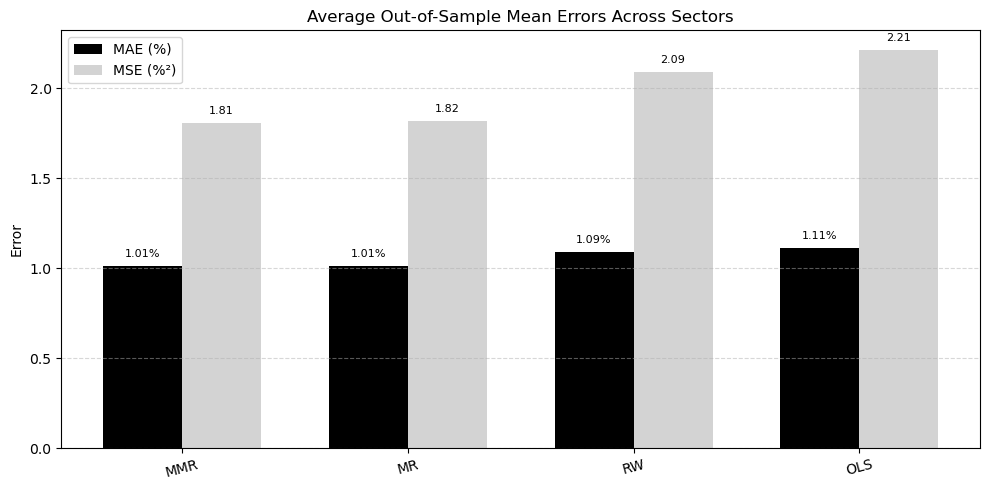

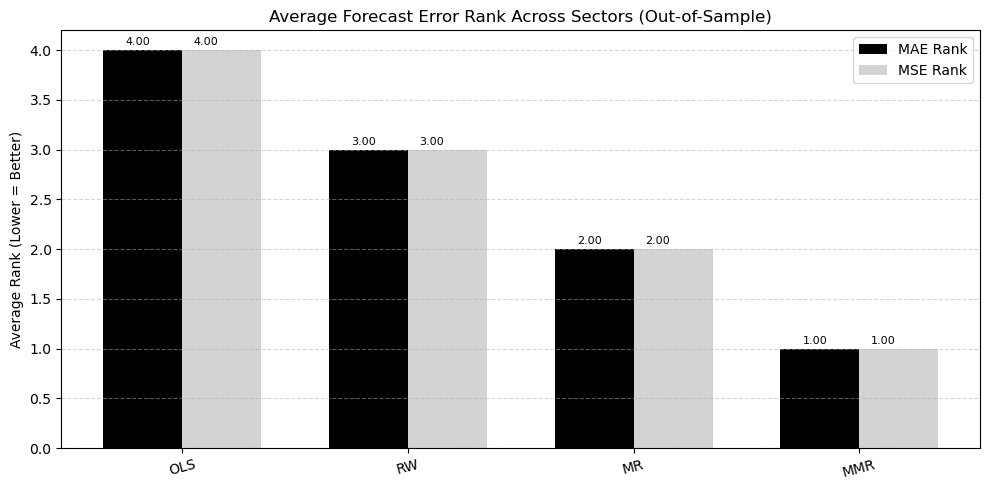

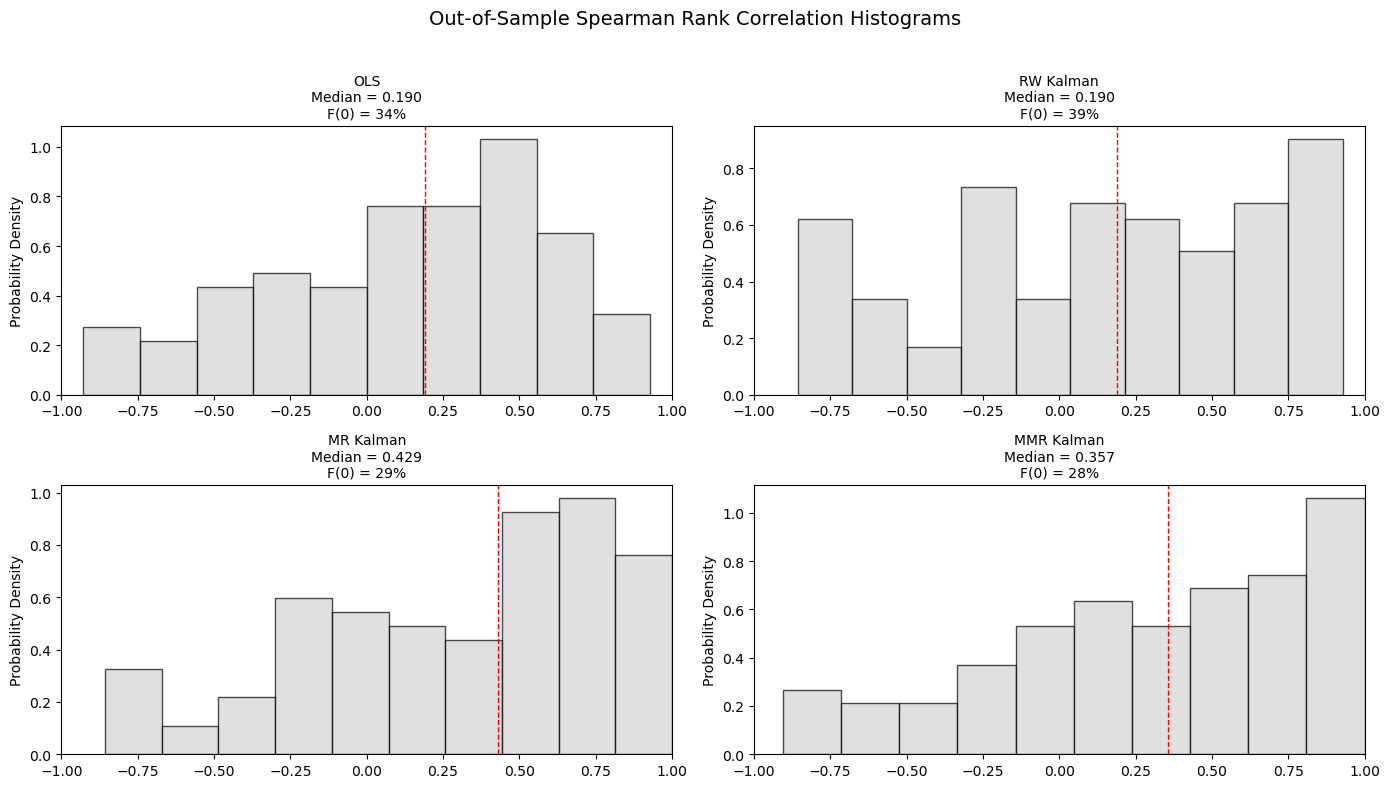

In [42]:
models = ["OLS", "RW", "MR", "MMR"]
avg_outsample = {"Model": [], "MAE (%)": [], "MSE (%²)": []}
for model in models:
    mae = multi_sector_outsample_df[f"{model}_MAE"].mean() * 100
    mse = multi_sector_outsample_df[f"{model}_MSE"].mean() * 10000
    avg_outsample["Model"].append(model)
    avg_outsample["MAE (%)"].append(mae)
    avg_outsample["MSE (%²)"].append(mse)
error_df_out = pd.DataFrame(avg_outsample).sort_values("MAE (%)")
x = np.arange(len(error_df_out))
width = 0.35
plt.figure(figsize=(10, 5))
bars_mae = plt.bar(x - width/2, error_df_out["MAE (%)"], width, label="MAE (%)", color="black")
bars_mse = plt.bar(x + width/2, error_df_out["MSE (%²)"], width, label="MSE (%²)", color="lightgray")
plt.xticks(x, error_df_out["Model"], rotation=15)
plt.ylabel("Error")
plt.title("Average Out-of-Sample Mean Errors Across Sectors", fontsize=12)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
for bar in bars_mae:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height():.2f}%', ha='center', fontsize=8)
for bar in bars_mse:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height():.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()
rank_df_out = error_df_out.copy()
rank_df_out["MAE Rank"] = rank_df_out["MAE (%)"].rank(method="min", ascending=True)
rank_df_out["MSE Rank"] = rank_df_out["MSE (%²)"].rank(method="min", ascending=True)
rank_df_sorted = rank_df_out.sort_values("MAE Rank", ascending=False).reset_index(drop=True)
x = np.arange(len(rank_df_sorted))
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, rank_df_sorted["MAE Rank"], width, label="MAE Rank", color="black")
plt.bar(x + width/2, rank_df_sorted["MSE Rank"], width, label="MSE Rank", color="lightgray")
plt.xticks(x, rank_df_sorted["Model"], rotation=15)
plt.ylabel("Average Rank (Lower = Better)")
plt.title("Average Forecast Error Rank Across Sectors (Out-of-Sample)", fontsize=12)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
for i in range(len(rank_df_sorted)):
    plt.text(x[i] - 0.25, rank_df_sorted["MAE Rank"][i] + 0.05,
             f'{rank_df_sorted["MAE Rank"][i]:.2f}', fontsize=8)
    plt.text(x[i] + 0.05, rank_df_sorted["MSE Rank"][i] + 0.05,
             f'{rank_df_sorted["MSE Rank"][i]:.2f}', fontsize=8)
plt.tight_layout()
plt.show()
all_test_beta = []
for sector, test_df in evaluated_test_df_dict.items():  
    sector_beta = test_df[["Date", "Excess_Return"]].copy()
    sector_beta["Sector"] = sector
    sector_beta["Market_Excess_Return"] = test_df["Market_Excess_Return"]
    for model in ["Beta_OLS", "Beta_RW", "Beta_MR", "Beta_MMR"]:
        if model in test_df.columns:
            sector_beta[model] = test_df[model]
    all_test_beta.append(sector_beta)
full_beta_df_test = pd.concat(all_test_beta)
valid_cols = [col for col in ["Beta_RW", "Beta_MR", "Beta_MMR"] if col in full_beta_df_test.columns]
full_beta_df_test = full_beta_df_test.dropna(subset=valid_cols, how='all')
def compute_spearman_series(df_all, model_col):
    result = []
    for date in sorted(df_all['Date'].unique()):
        temp = df_all[df_all['Date'] == date]
        if temp.shape[0] < 5 or model_col not in temp.columns:
            continue
        pred = temp[model_col] * temp['Market_Excess_Return']
        actual = temp["Excess_Return"]
        rho, _ = spearmanr(pred, actual)
        result.append(rho)
    return pd.Series(result)
spearman_dict_time = {
    "OLS": compute_spearman_series(full_beta_df_test, "Beta_OLS"),
    "RW": compute_spearman_series(full_beta_df_test, "Beta_RW"),
    "MR": compute_spearman_series(full_beta_df_test, "Beta_MR"),
    "MMR": compute_spearman_series(full_beta_df_test, "Beta_MMR"),
}
def plot_spearman_hist(rho_series, model_name, ax):
    vals = rho_series.dropna()
    median_val = vals.median()
    f0 = (vals < 0).mean() * 100
    ax.hist(vals, bins=10, density=True, edgecolor='black', alpha=0.7, color="lightgray")
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{model_name}\nMedian = {median_val:.3f}\nF(0) = {f0:.0f}%", fontsize=10)
    ax.set_xlim([-1, 1])
    ax.set_ylabel("Probability Density")
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_spearman_hist(spearman_dict_time["OLS"], "OLS", axes[0, 0])
plot_spearman_hist(spearman_dict_time["RW"], "RW Kalman", axes[0, 1])
plot_spearman_hist(spearman_dict_time["MR"], "MR Kalman", axes[1, 0])
plot_spearman_hist(spearman_dict_time["MMR"], "MMR Kalman", axes[1, 1])
fig.suptitle("Out-of-Sample Spearman Rank Correlation Histograms", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()